<a href="https://colab.research.google.com/github/SunneyGao/ECE364/blob/main/A1/A1_ECE364_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prepare python environment


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

%matplotlib inline

In [2]:
random_state=5 # use this to control randomness across runs e.g., dataset partitioning

## Preparing the Glass Dataset (2 points)

---


We will use glass dataset from UCI machine learning repository. Details for this data can be found [here](https://archive.ics.uci.edu/dataset/42/glass+identification).
The objective of the dataset is to identify the class of glass based on the following features:

1. RI: refractive index
2. Na: Sodium
3. Mg: Magnesium
4. Al: Aluminum
5. Si: Silica
6. K: Potassium
7. Ca: Calcium
8. Ba: Barium
9. Fe: Iron
10. Type of glass (Target label)

The classes of glass are:

1. building_windows_float_processed
2. building_windows_non_float_processed
3. vehicle_windows_float_processed
4. containers
5. tableware
6. headlamps

Identification of glass from its content can be used for forensic analysis.

### Loading the dataset

In [3]:
# Download and load the dataset
import os
if not os.path.exists('glass.csv'):
    !wget https://raw.githubusercontent.com/JHA-Lab/ece364_2026/master/data/glass.csv
data = pd.read_csv('glass.csv')

# Display the first five instances in the dataset
data.head(5)

--2026-09-28 04:48:51--  https://raw.githubusercontent.com/JHA-Lab/ece364_2026/master/data/glass.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9838 (9.6K) [text/plain]
Saving to: ‘glass.csv’

glass.csv           100%[===================>]   9.61K  --.-KB/s    in 0s      

2026-09-28 04:48:51 (61.1 MB/s) - ‘glass.csv’ saved [9838/9838]



,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


# Adding Additional Features

1. Ca_Na: Calcium Sodium
2. Al_Mg: Aluminum Magnesium
3. Ca_Mg: Calcium Magnesium

In [5]:
# Additional features to be added to the data
data['Ca_Na'] = data.Ca*data.Na
data['Al_Mg'] = data.Al*data.Mg
data['Ca_Mg'] = data.Ca*data.Mg

# get column names
col_names = data.columns

### Check the data type for each column

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
 10  Ca_Na   214 non-null    float64
 11  Al_Mg   214 non-null    float64
 12  Ca_Mg   214 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 21.9 KB


#### Look at some statistics of the data using the `describe` function in pandas.

In [7]:
data.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type,Ca_Na,Al_Mg,Ca_Mg
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374,119.775005,3.533553,23.138600
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739,17.796541,2.075049,12.465510
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000,74.336700,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000,108.515575,2.378700,19.124100
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000,113.256650,4.149700,28.835250
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000,129.368700,4.922325,30.687825
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000,199.137000,9.380000,39.287500


1. Count tells us the number of Non-empty rows in a feature.

2. Mean tells us the mean value of that feature.

3. Std tells us the Standard Deviation Value of that feature.

4. Min tells us the minimum value of that feature.

5. 25%, 50%, and 75% are the percentile/quartile of each feature.

6. Max tells us the maximum value of that feature.

### Visualize the Data

#### Check how many instances of each target class are there in the data. This has been done for you.

Text(0, 0.5, 'Count')

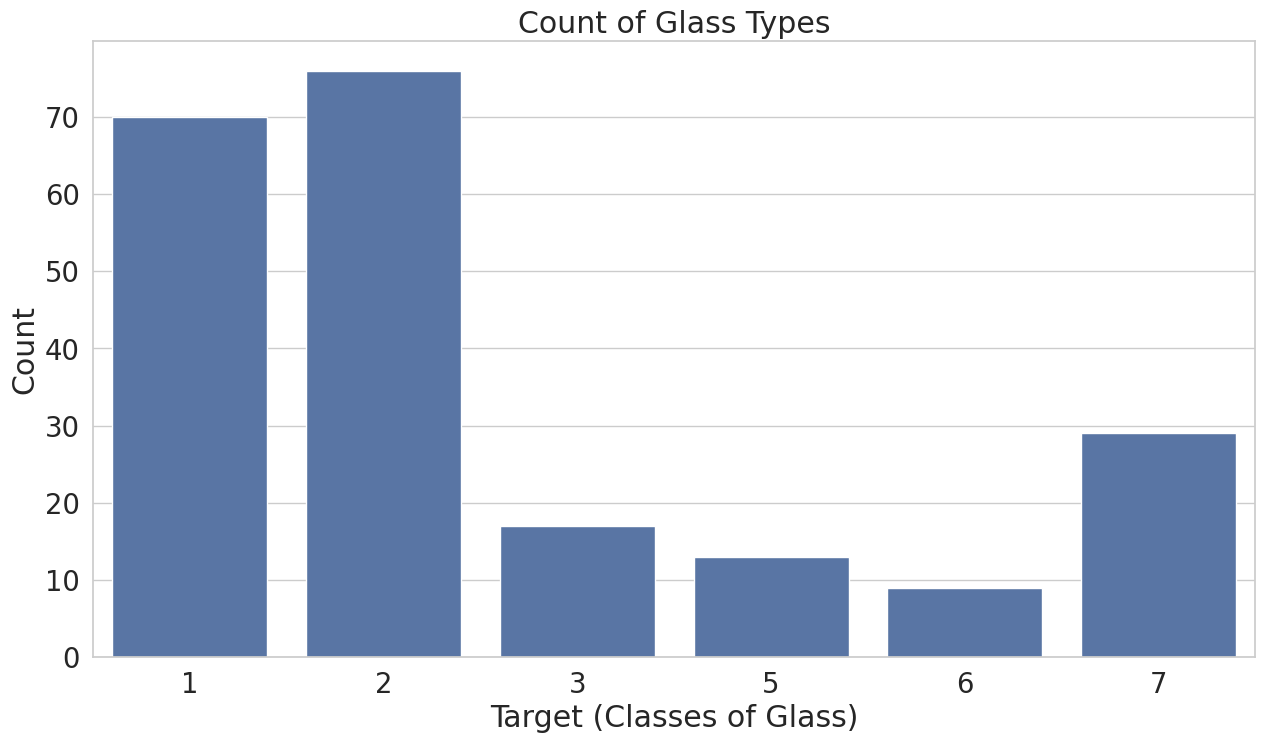

In [8]:
sns.set_theme(style="whitegrid", font_scale=1.8)
plt.subplots(figsize = (15,8))
sns.countplot(x='Type',data=data).set_title('Count of Glass Types')
plt.xlabel('Target (Classes of Glass)')
plt.ylabel('Count')

#### Calculate `mean` values for each feature grouped by target. This has been done for you.

In [9]:
# Compute mean values for each feature grouped by target
data.groupby('Type', as_index=False).mean()

,Type,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Ca_Na,Al_Mg,Ca_Mg
0,1,1.518718,13.242286,3.552429,1.163857,72.619143,0.447429,8.797286,0.012714,0.057000,116.590990,4.108247,31.271384
1,2,1.518619,13.111711,3.002105,1.408158,72.598026,0.521053,9.073684,0.050263,0.079737,118.402543,4.333504,25.144126
2,3,1.517964,13.437059,3.543529,1.201176,72.404706,0.406471,8.782941,0.008824,0.057059,118.137300,4.217241,31.159494
3,5,1.518928,12.827692,0.773846,2.033846,72.366154,1.470000,10.123846,0.187692,0.060769,129.290469,1.724108,7.311938
4,6,1.517456,14.646667,1.305556,1.366667,73.206667,0.000000,9.356667,0.000000,0.000000,136.140600,1.988589,12.059867
5,7,1.517116,14.442069,0.538276,2.122759,72.965862,0.325172,8.491379,1.040000,0.013448,122.672859,0.939755,4.082914


#### Create box plots to see distribution of each feature. See [here](https://seaborn.pydata.org/generated/seaborn.boxplot.html) for further details. This has been done for you.

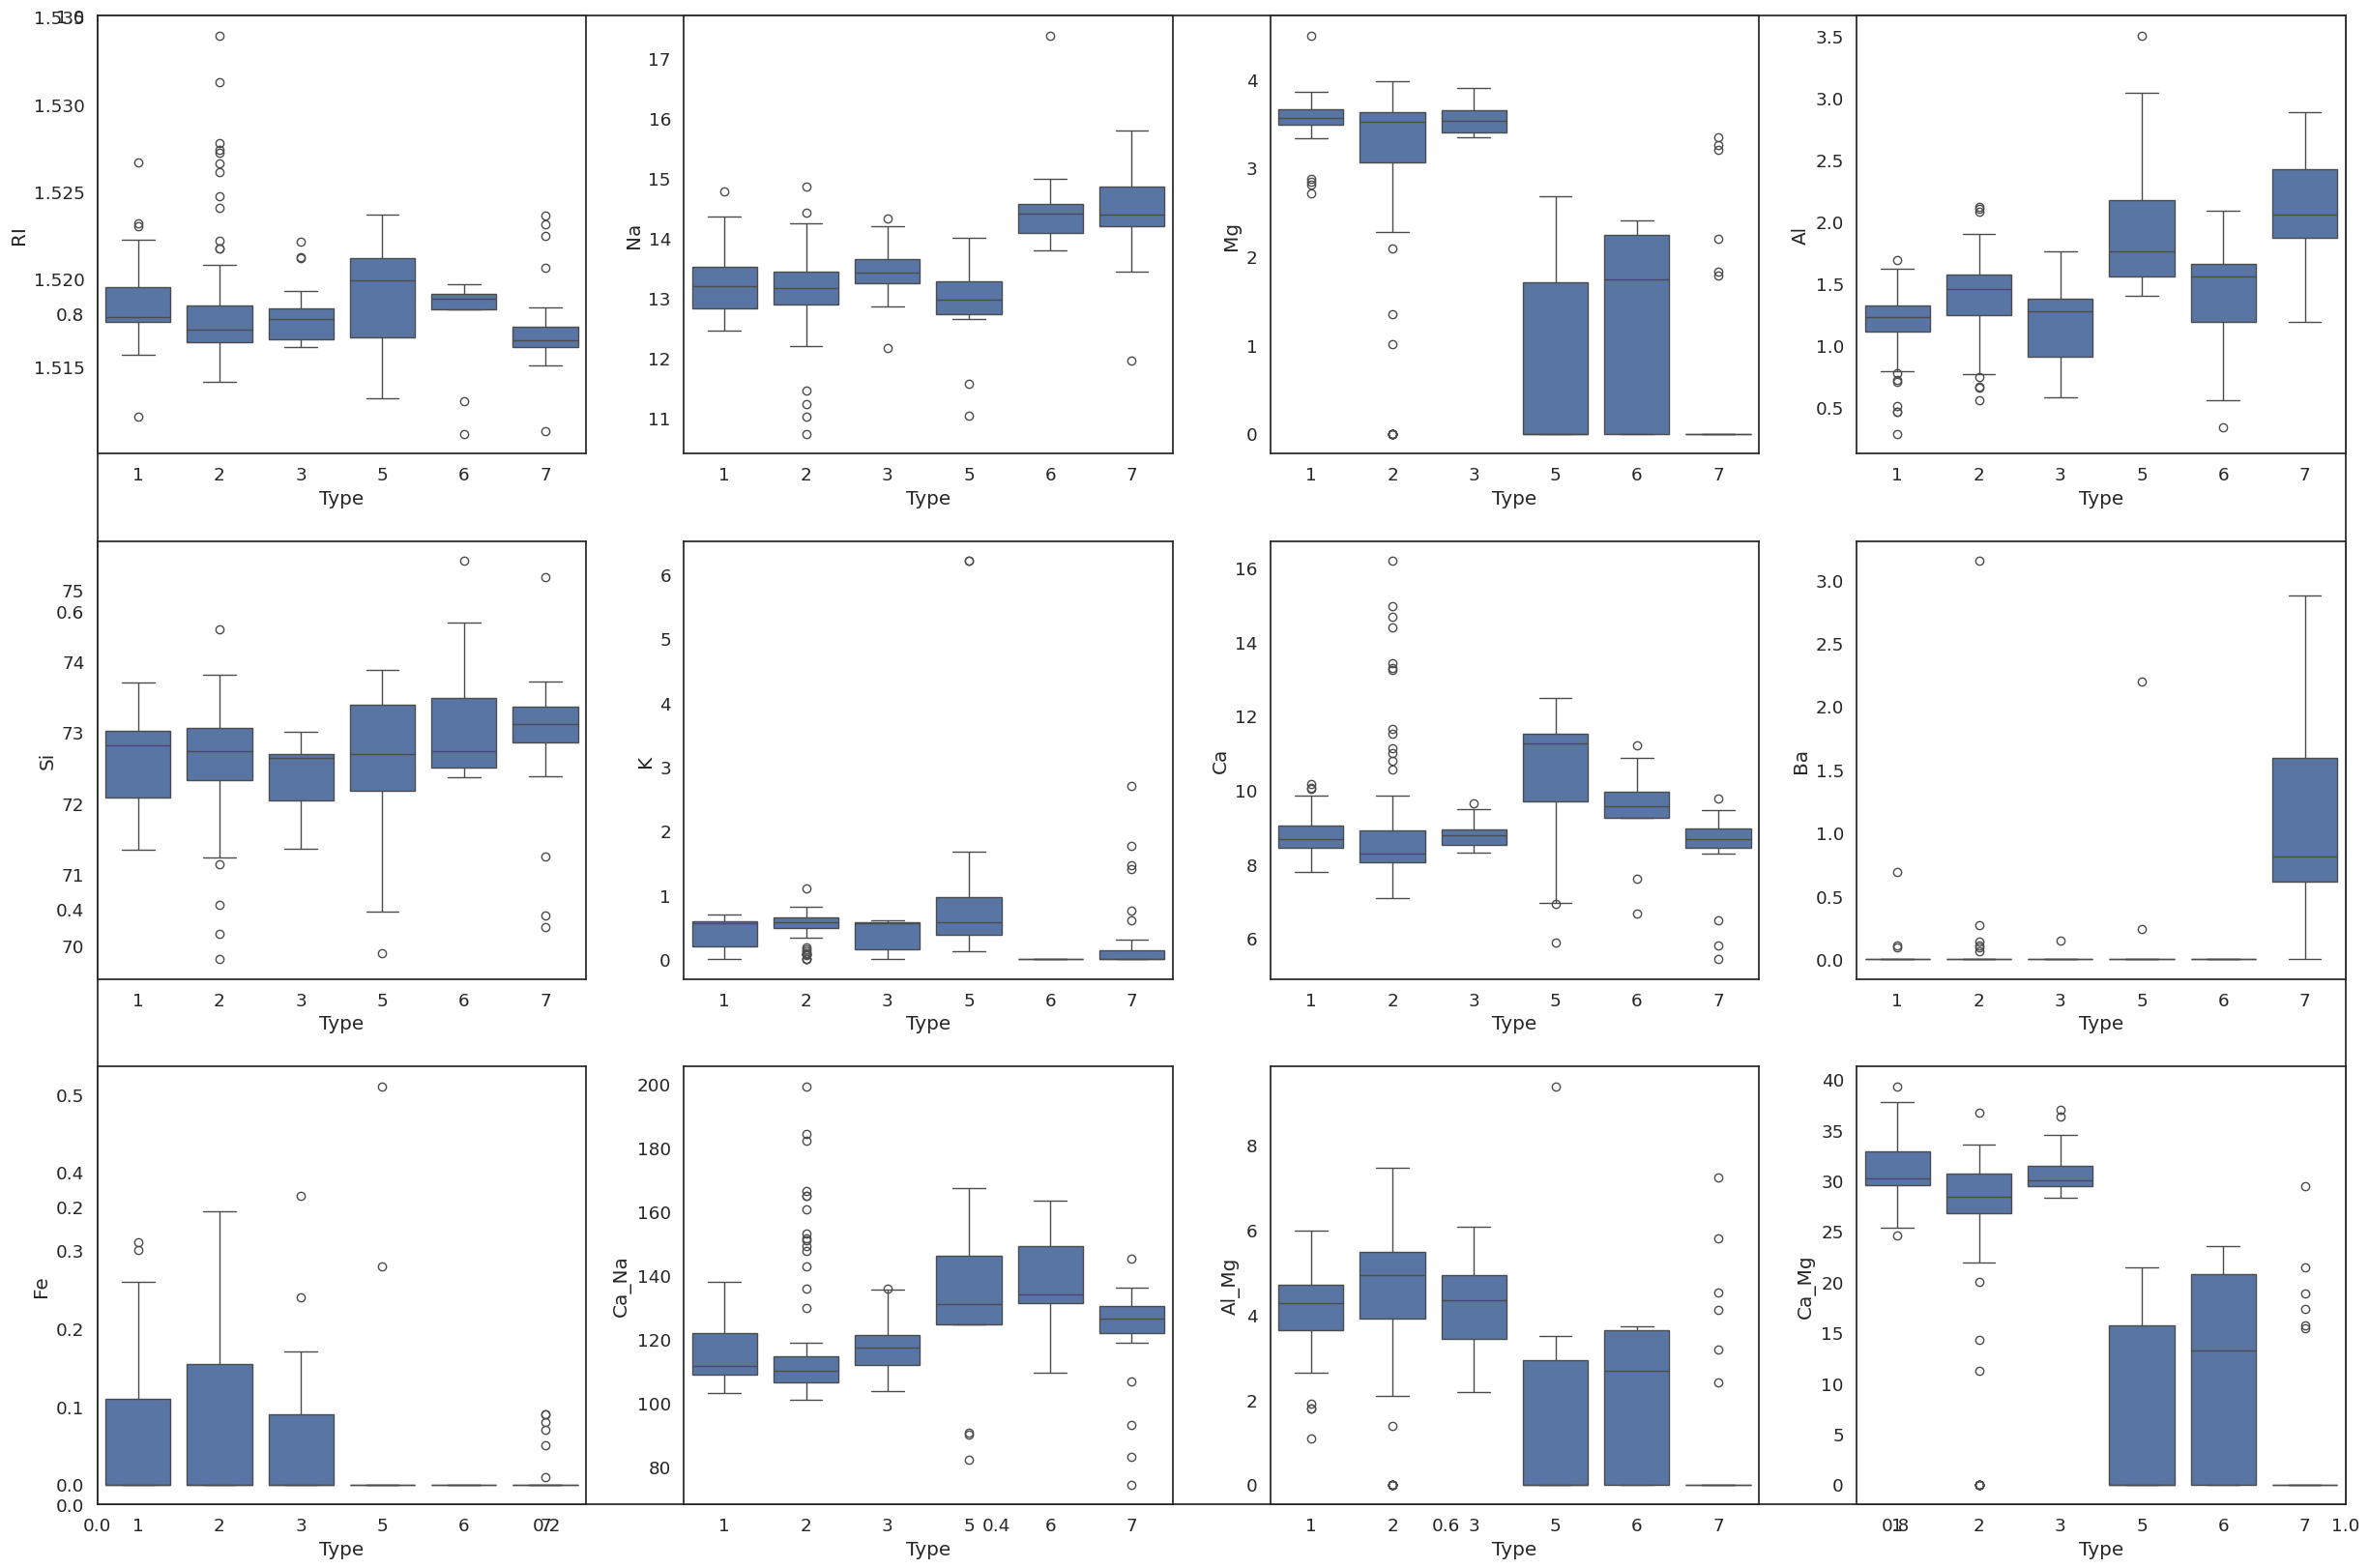

In [10]:
sns.set_theme(style="white", font_scale=1.2)
plt.subplots(figsize = (30,20))
plt.subplot(3,4,1)
sns.boxplot(x='Type', y='RI', data=data)
plt.subplot(3,4,2)
sns.boxplot(x='Type', y='Na', data=data)
plt.subplot(3,4,3)
sns.boxplot(x='Type', y='Mg', data=data)
plt.subplot(3,4,4)
sns.boxplot(x='Type', y='Al', data=data)
plt.subplot(3,4,5)
sns.boxplot(x='Type', y='Si', data=data)
plt.subplot(3,4,6)
sns.boxplot(x='Type', y='K', data=data)
plt.subplot(3,4,7)
sns.boxplot(x='Type', y='Ca', data=data)
plt.subplot(3,4,8)
sns.boxplot(x='Type', y='Ba', data=data)
plt.subplot(3,4,9)
sns.boxplot(x='Type', y='Fe', data=data)
plt.subplot(3,4,10)
sns.boxplot(x='Type', y='Ca_Na', data=data)
plt.subplot(3,4,11)
sns.boxplot(x='Type', y='Al_Mg', data=data)
plt.subplot(3,4,12)
sns.boxplot(x='Type', y='Ca_Mg', data=data)
plt.show()

#### Create a pairplot to display pairwise relationship. See [here](https://seaborn.pydata.org/generated/seaborn.pairplot.html) for further details. This has been done for you.

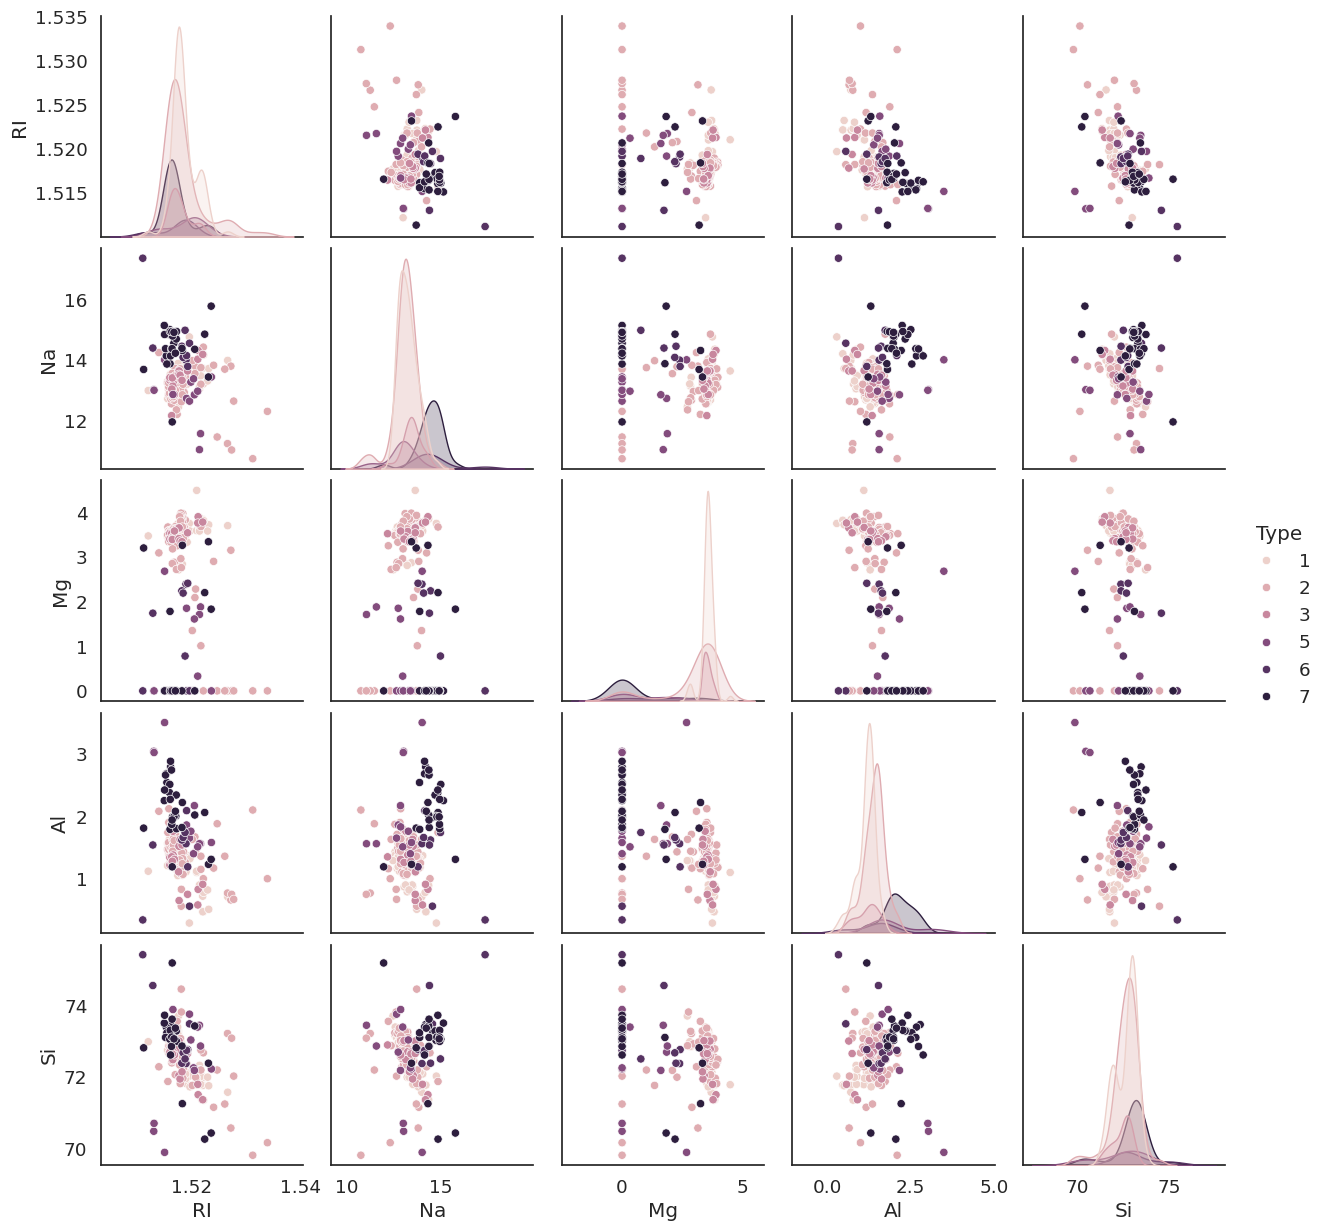

In [11]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
# Select a subset of features for visualization
sns.pairplot(data[['RI','Na','Mg','Al','Si','Type']], hue='Type')

<Axes: >

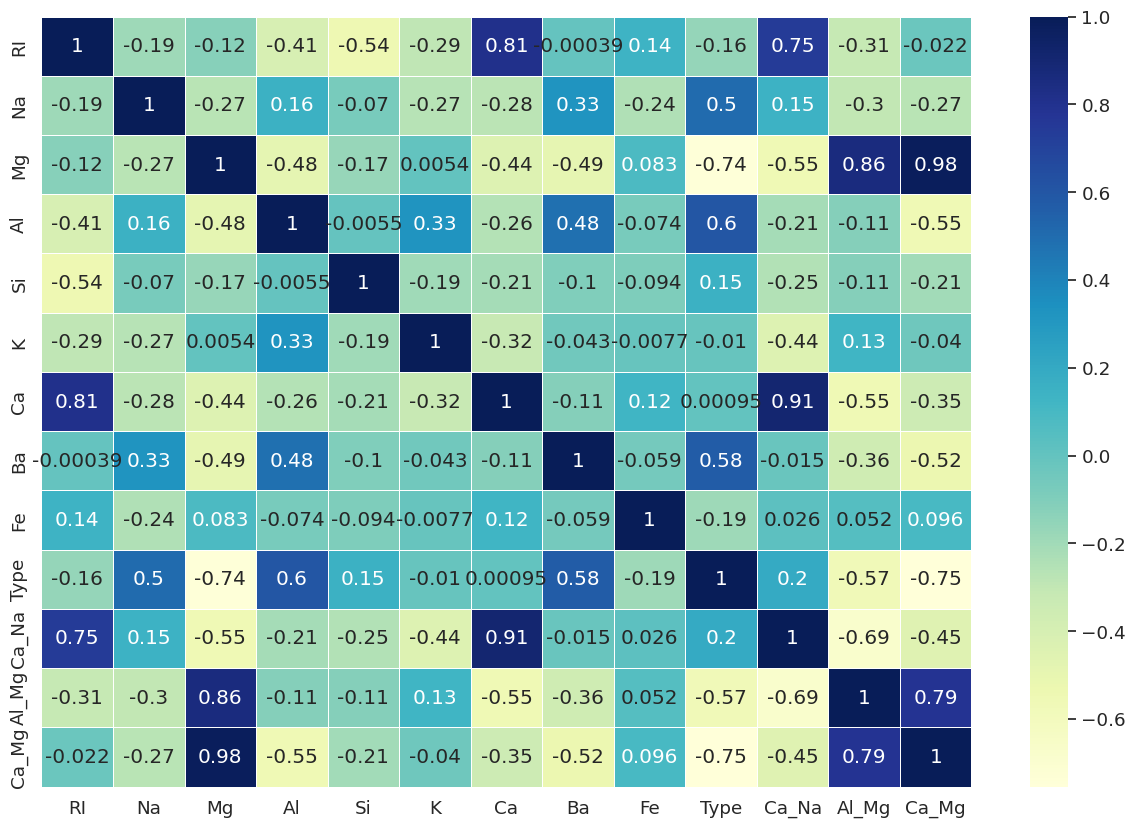

In [12]:
# Plot heatmap showing correlation between different features
plt.subplots(figsize=(15,10))
sns.heatmap(data.corr(),cmap='YlGnBu',annot=True, linewidth=.5)

### Extract target and descriptive features (1 point)

#### Separate the target and features from the data.

In [14]:
# Store all the features from the data in X
X = data.drop('Type',axis=1)

# Store all the labels in y
y = data.Type

In [15]:
# Convert data to numpy array
X = X.to_numpy()
y = y.to_numpy()

### Create training and validation datasets (1 point)


We will split the dataset into training and validation set. Generally in machine learning, we split the data into training,
validation and test set (this will be covered in later chapters). The model with best performance on the validation set is used to evaluate perfromance on
the test set which is the unseen data. In this assignment, we will using `train set` for training and evaluate the performance on the `validation set` for various
model configurations to determine the best hyperparameters (parameter setting yielding the best performance).

Split the data into training and validation set using `train_test_split`.  See [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) for details. To get consistent result while splitting, set `random_state` to the value defined earlier. We use 80% of the data for training and 20% of the data for validation. This has been done for you.

In [16]:
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=.2,random_state=random_state) # 80% training and 20% validation

## Training Decision Tree-based Classifiers (18 points)


### Exercise 1: Learning a Decision Tree (10 points)

#### We will use the `sklearn` library to train a Decision Tree classifier. Review ch.4 and see [here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) for more details.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [19]:
# tree visualization helper function
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

"""
clf: DecisionTreeClassifier

Returns a bytes object representing the image of the tree
"""
def get_tree_image(clf):
    dot_data = StringIO()
    feature_names=data.drop('Type',axis=1).columns
    class_names=["Building_windows_float_processed", "Building_windows_non_float_processed", "Vehicle_windows_float_processed", "Containers", "Tableware", "Headlamps"]
    export_graphviz(clf, out_file=dot_data,
                    filled=True, rounded=True,
                    special_characters=True,
                    feature_names=feature_names,
                    class_names=class_names)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())


    return graph.create_png()

#### Exercise 1a: Fit and interpret a decision tree. (6 points)

#### Fit Decision trees using the Gini index and entropy-based impurity measure.

#### Set the random_state to the value defined above. Keep all other parameters at their default values.

#### Report the training and validation set accuracies for each classifier.

In [32]:
# Gini Index
gini_clf = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=None,
                                  min_samples_split=2, min_samples_leaf=1,
                                  min_weight_fraction_leaf=0.0, max_features=None,
                                  random_state= random_state, max_leaf_nodes=None,
                                  min_impurity_decrease=0.0, class_weight=None,
                                  ccp_alpha=0.0, monotonic_cst=None)
gini_clf.fit(X_train, y_train)

print("Gini Training Accuracy: ", gini_clf.score(X_train, y_train))
print("Gini Validation Accuracy: ", gini_clf.score(X_val, y_val))

# Entropy
entropy_clf = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                     max_depth=None, min_samples_split=2,
                                     min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                     max_features=None, random_state= random_state,
                                     max_leaf_nodes=None, min_impurity_decrease=0.0,
                                     class_weight=None, ccp_alpha=0.0,
                                     monotonic_cst=None)
entropy_clf.fit(X_train, y_train)

print("Entropy Training Accuracy: ", entropy_clf.score(X_train, y_train))
print("Entropy Validation Accuracy: ", entropy_clf.score(X_val, y_val))

Gini Training Accuracy:  1.0
Gini Validation Accuracy:  0.7209302325581395
Entropy Training Accuracy:  1.0
Entropy Validation Accuracy:  0.7674418604651163


#### Visualize the Decision Tree with the best validation performance.

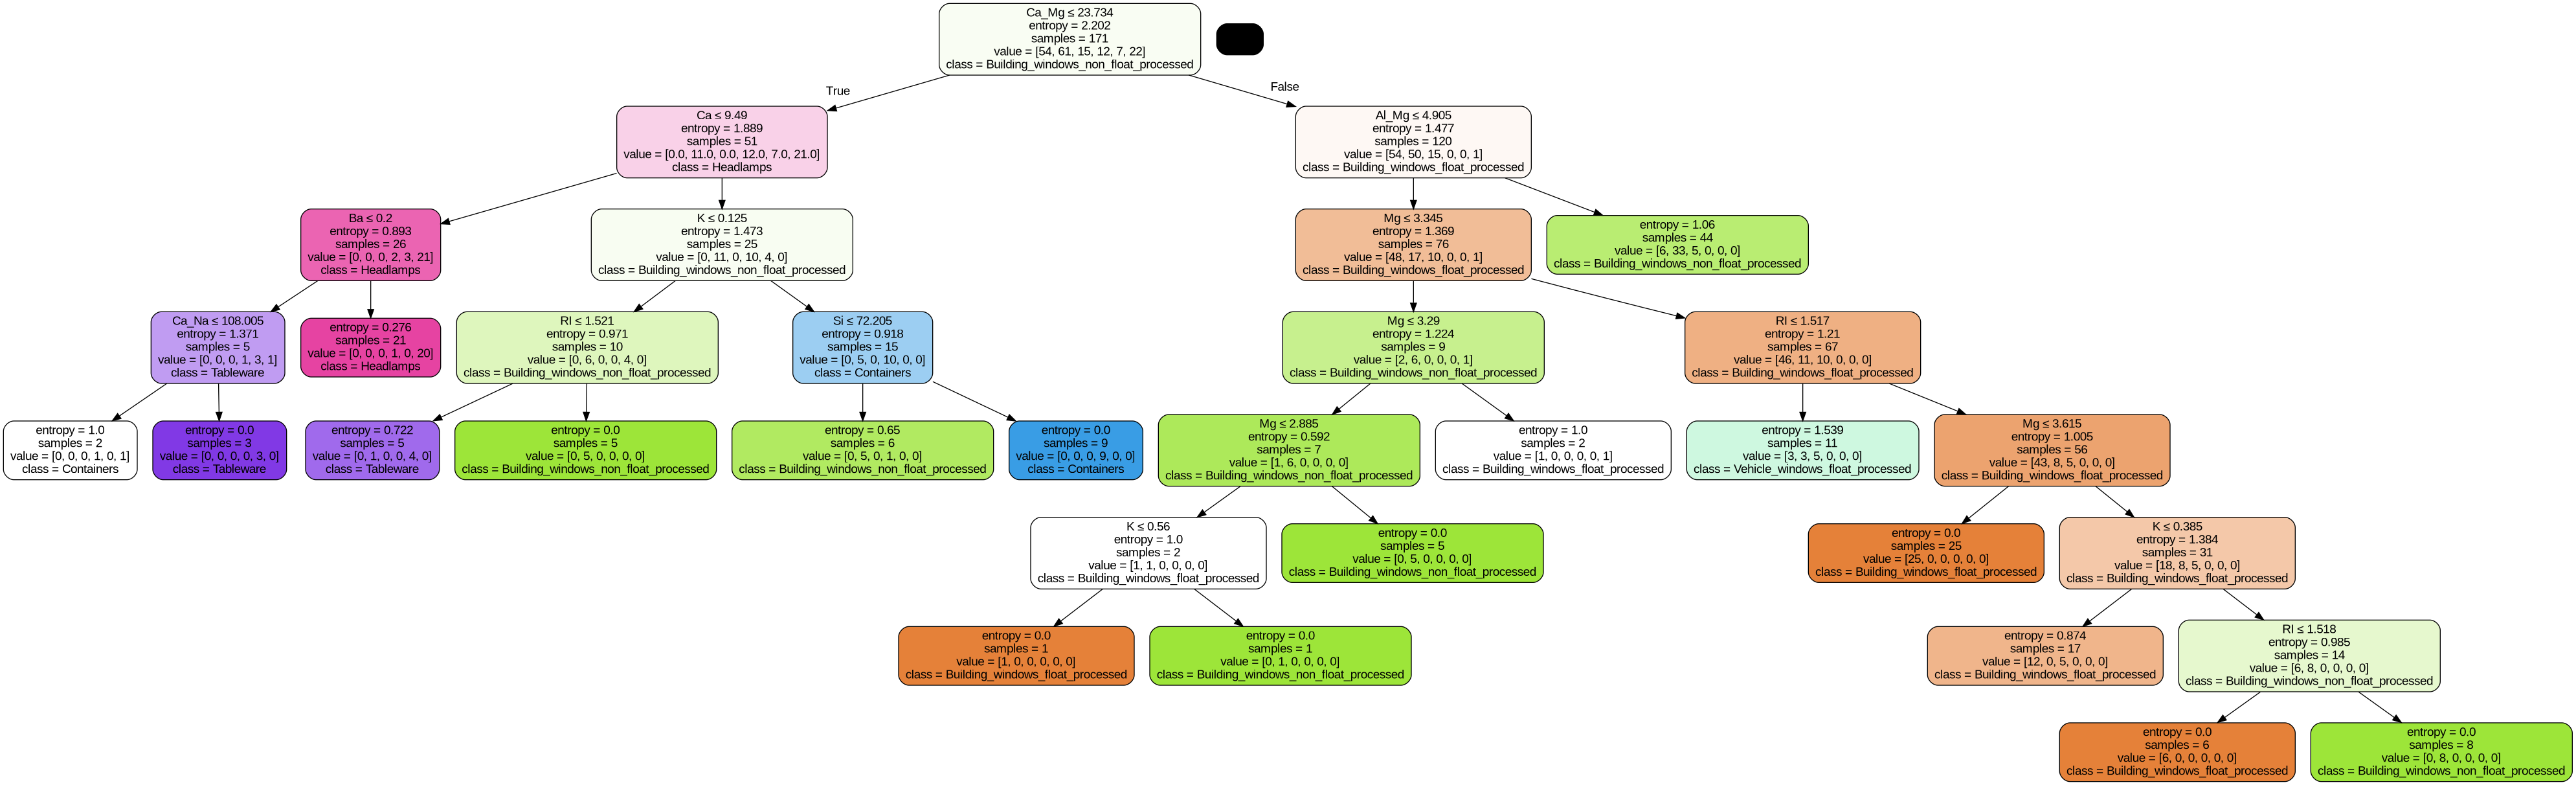

In [49]:
best_clf=entropy_clf
tree_image=get_tree_image(best_clf)
Image(tree_image)

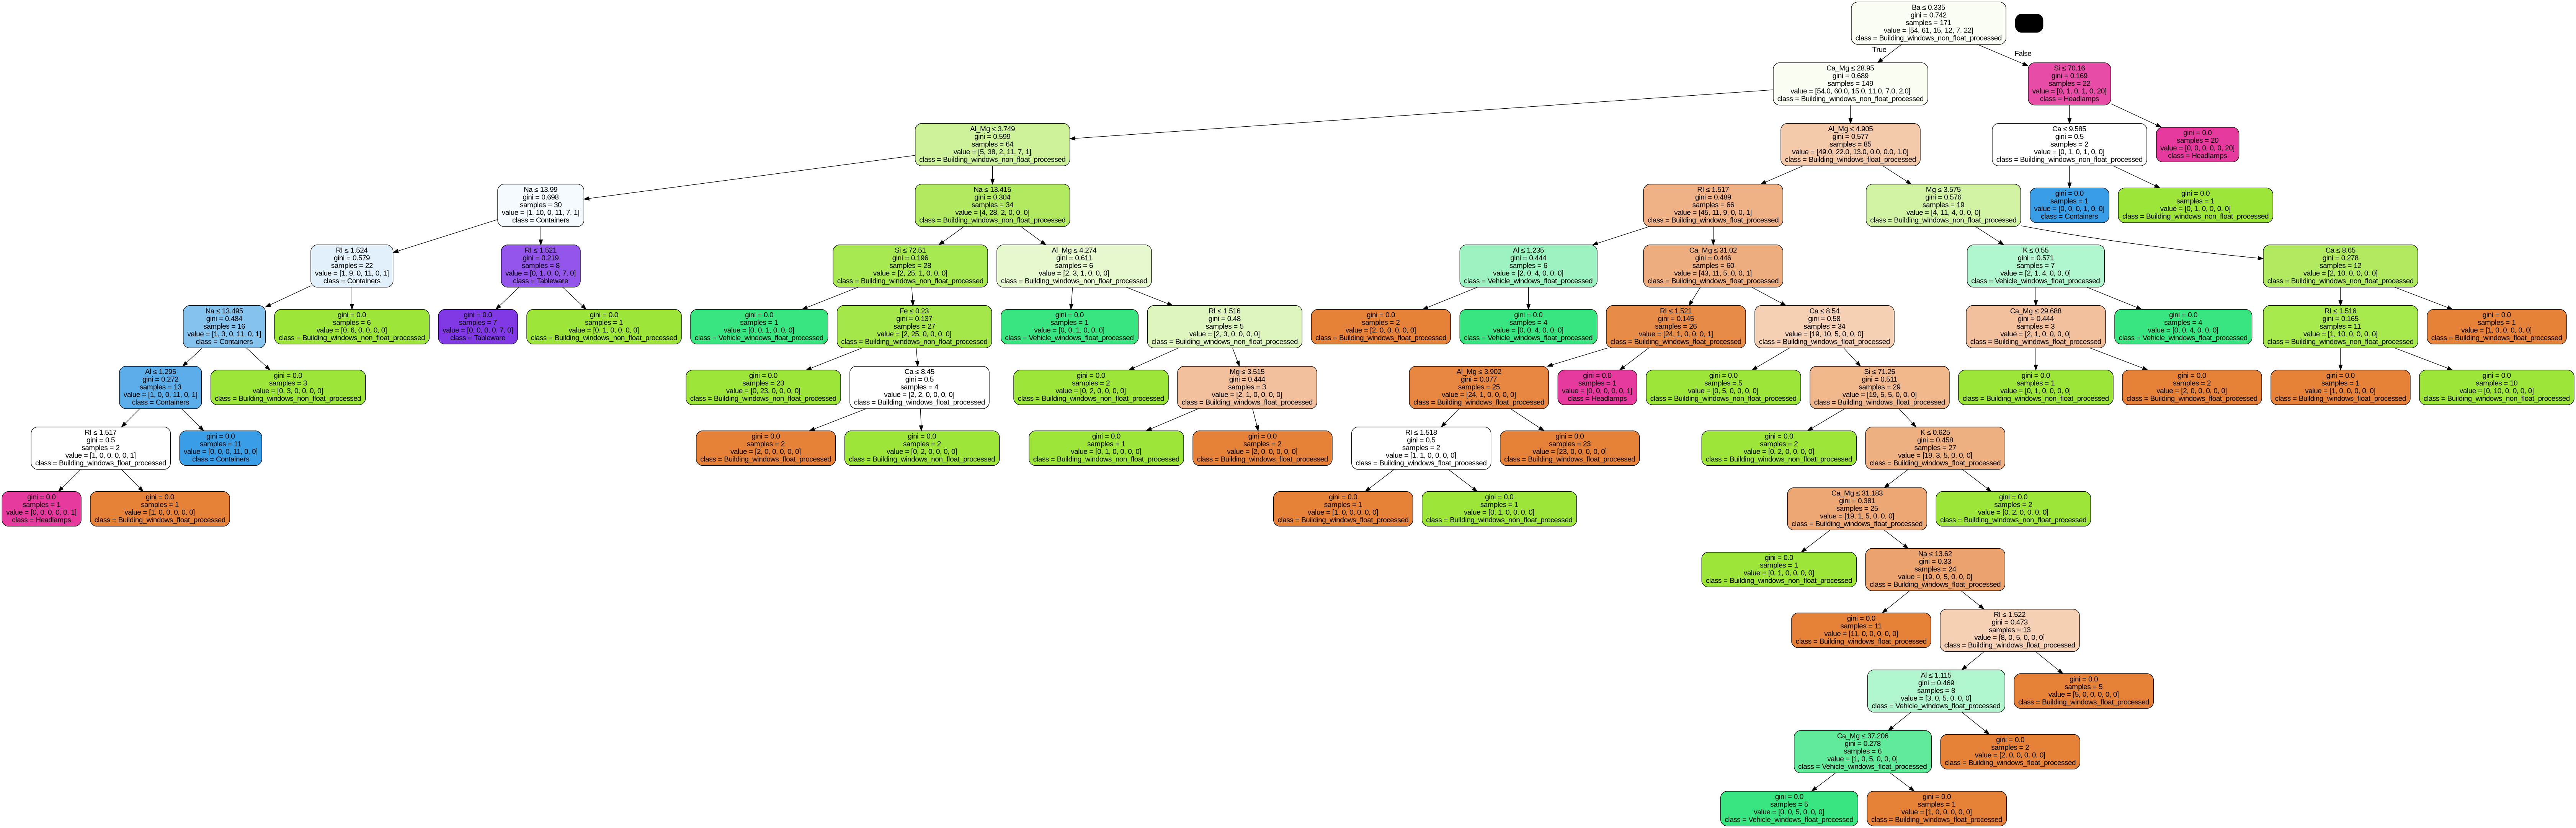

In [28]:
best_clf=gini_clf
tree_image=get_tree_image(best_clf)
Image(tree_image)

#### Indicate the most informative descriptive feature (with the threshold) and briefly explain why this is the most informative (from an algorithmic viewpoint).

**Answer:** For the Entropy tree (tree with the best validation performance), the most informative descriptive feature is Ca_Mg, with the threshold being Ca_Mg $\leq$ 23.734. From an algorithmic viewpoint, this is most informative because when the tree is built, the ID3 algorithm tries every feature and threshold at each node and picks the partition with the highest information gain. Since info gain = entropy before partition minus the remainder (weighted average entropy of new child nodes), we see that Ca_Mg reduces entropy the most of any available partition.

#### Briefly comment on the tree's depth and what factors may contribute to the shallowness/complexity of the tree.


**Answer:** The tree is of depth 9 (entropy tree). This may be because the descriptive features are continuous which allows for many thresholds. We also set max_depth = None and min_samples_leaf=1 so the tree would keep partitioning until we get a perfect fit. Classes 1, 2, and 3 are also very similar in their descriptive features as seen in the box plots, so we need more detailed partitions to differentiate. Finally, Classes 3, 5, and 6 have <20 samples compared to 30-70 samples for the other Classes, so the tree has to create small leaves for individual points.



#### Show how one can interpret the tree by specifying the rule from its left most branch.

**Answer:** If Ca_Mg $\leq$ 23.734 and Ca $\leq$ 9.49 and Ba $\leq$ 0.2 and Ca_Na $\leq$ 108.005 and K $\leq$ 4.455 then class = Headlamps (Class 7 *since Type skips Type = 4)

#### Exercise 1b: Preprune a decision tree. (2 points)

#### Next, let's try pruning the tree to see if we can improve the classifier's generalization performance.

#### Preprune a decision tree by varying the `max_depth` among {None (no depth control), 1,3,5,7}.

#### Set the criterion to entropy and the random_state to the value defined above. Keep all other parameters at their default values.

#### Report the training and validation set accuracies for each classifier.

In [34]:
# Entropy
# max_depth = None
entropy_clf_none = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                     max_depth=None, min_samples_split=2,
                                     min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                     max_features=None, random_state= random_state,
                                     max_leaf_nodes=None, min_impurity_decrease=0.0,
                                     class_weight=None, ccp_alpha=0.0,
                                     monotonic_cst=None)
entropy_clf_none.fit(X_train, y_train)

print("Entropy_NoMax Training Accuracy: ", entropy_clf_none.score(X_train, y_train))
print("Entropy_NoMax Validation Accuracy: ", entropy_clf_none.score(X_val, y_val))

# max_depth = 7
entropy_clf_7 = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                     max_depth=7, min_samples_split=2,
                                     min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                     max_features=None, random_state= random_state,
                                     max_leaf_nodes=None, min_impurity_decrease=0.0,
                                     class_weight=None, ccp_alpha=0.0,
                                     monotonic_cst=None)
entropy_clf_7.fit(X_train, y_train)

print("Entropy_7 Training Accuracy: ", entropy_clf_7.score(X_train, y_train))
print("Entropy_7 Validation Accuracy: ", entropy_clf_7.score(X_val, y_val))

# max_depth = 5
entropy_clf_5 = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                     max_depth=5, min_samples_split=2,
                                     min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                     max_features=None, random_state= random_state,
                                     max_leaf_nodes=None, min_impurity_decrease=0.0,
                                     class_weight=None, ccp_alpha=0.0,
                                     monotonic_cst=None)
entropy_clf_5.fit(X_train, y_train)

print("Entropy_5 Training Accuracy: ", entropy_clf_5.score(X_train, y_train))
print("Entropy_5 Validation Accuracy: ", entropy_clf_5.score(X_val, y_val))

# max_depth = 3
entropy_clf_3 = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                     max_depth=3, min_samples_split=2,
                                     min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                     max_features=None, random_state= random_state,
                                     max_leaf_nodes=None, min_impurity_decrease=0.0,
                                     class_weight=None, ccp_alpha=0.0,
                                     monotonic_cst=None)
entropy_clf_3.fit(X_train, y_train)

print("Entropy_3 Training Accuracy: ", entropy_clf_3.score(X_train, y_train))
print("Entropy_3 Validation Accuracy: ", entropy_clf_3.score(X_val, y_val))

# max_depth = 1
entropy_clf_1 = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                     max_depth=1, min_samples_split=2,
                                     min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                     max_features=None, random_state= random_state,
                                     max_leaf_nodes=None, min_impurity_decrease=0.0,
                                     class_weight=None, ccp_alpha=0.0,
                                     monotonic_cst=None)
entropy_clf_1.fit(X_train, y_train)

print("Entropy_1 Training Accuracy: ", entropy_clf_1.score(X_train, y_train))
print("Entropy_1 Validation Accuracy: ", entropy_clf_1.score(X_val, y_val))

Entropy_NoMax Training Accuracy:  1.0
Entropy_NoMax Validation Accuracy:  0.7674418604651163
Entropy_7 Training Accuracy:  0.9824561403508771
Entropy_7 Validation Accuracy:  0.7906976744186046
Entropy_5 Training Accuracy:  0.8830409356725146
Entropy_5 Validation Accuracy:  0.7441860465116279
Entropy_3 Training Accuracy:  0.7251461988304093
Entropy_3 Validation Accuracy:  0.6511627906976745
Entropy_1 Training Accuracy:  0.43859649122807015
Entropy_1 Validation Accuracy:  0.5348837209302325


#### Analyze the effect of increasing tree depth on training and validation performance.

**Answer:** As tree depth increases, training performance increases from 0.439 at max_depth = 1 to 1.0 at no max tree depth because a deeper tree can keep partitioning training data until it gets "perfect" partitions. Validation performance follows a different trend, increasing with tree depth increase at first, from 0.535 at max_depth = 1 to a peak of 0.79 at max_depth = 7. However, we see a dip in validation accuracy when there's no max tree depth. This is because shallow trees are too simple and underfit, causing low training and validation performance, but the unlimited depth tree overfits on the training data (hence the 100% accuracy on the training data) but memorizes noise that doesn't carry over to the validation data. Depth 7 seems best here.

Also interesting: depth 1 has higher validation accuracy than training accuracy, but could be due to chance.

#### Exercise 1c: Postprune a decision tree. (2 points)

#### Implement reduced error pruning on the two decision trees that you previously trained in Exercise 1a. Use the validation set to decide which nodes to prune.

#### Report the validation set accuracies for each classifier after pruning.

#### The pruning function is partly writen, please fill in the TODO part. Review ch.4.4.4 for more details.


In [35]:
# Fit new trees if you want to keep the trees in 1a unmodified
gini_clf = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=None,
                                  min_samples_split=2, min_samples_leaf=1,
                                  min_weight_fraction_leaf=0.0, max_features=None,
                                  random_state= random_state, max_leaf_nodes=None,
                                  min_impurity_decrease=0.0, class_weight=None,
                                  ccp_alpha=0.0, monotonic_cst=None)
gini_clf.fit(X_train, y_train)

print("Gini Training Accuracy: ", gini_clf.score(X_train, y_train))
print("Gini Validation Accuracy: ", gini_clf.score(X_val, y_val))


entropy_clf = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                     max_depth=None, min_samples_split=2,
                                     min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                     max_features=None, random_state= random_state,
                                     max_leaf_nodes=None, min_impurity_decrease=0.0,
                                     class_weight=None, ccp_alpha=0.0,
                                     monotonic_cst=None)
entropy_clf.fit(X_train, y_train)

print("Entropy Training Accuracy: ", entropy_clf.score(X_train, y_train))
print("Entropy Validation Accuracy: ", entropy_clf.score(X_val, y_val))


def reduced_error_pruning(dtree, X_val, y_val):
    """
    Perform reduced error pruning on a decision tree classifier.

    This function directly modifies the decision tree passed as an argument.

    Args:
    dtree: DecisionTreeClassifier
        The decision tree to prune, must be already fitted.
    X_val: array-like
        Validation features used to prune the tree.
    y_val: array-like
        Validation labels used to determine pruning effectiveness.

    Returns:
    dtree: DecisionTreeClassifier
        The pruned decision tree.
    """

    # Access the internal tree structure to identify non-leaf nodes
    non_leaf_nodes = [i for i in range(dtree.tree_.node_count) if dtree.tree_.children_left[i] != dtree.tree_.children_right[i]]

    # Track the best accuracy and corresponding tree configuration. initialize with original accuracy.
    best_acc = dtree.score(X_val, y_val)

    # Iterate over non-leaf nodes in reverse order to consider pruning from the bottom up
    for i in reversed(non_leaf_nodes):
        # Store current node children to restore if needed
        left, right = dtree.tree_.children_left[i], dtree.tree_.children_right[i]

        # Temporarily make the node a leaf
        dtree.tree_.children_left[i], dtree.tree_.children_right[i] = -1, -1

        # Calculate the accuracy of the tree with the node pruned (turned into a leaf)
        temp_acc = dtree.score(X_val, y_val)

        if temp_acc < best_acc: # Revert pruning if accuracy decreases
            # Restore the node to its original state
            dtree.tree_.children_left[i], dtree.tree_.children_right[i] = left, right
        else:
            # Update the best accuracy observed
            best_acc = temp_acc

    return dtree  # Return the modified tree


pruned_entropy = reduced_error_pruning(entropy_clf, X_val, y_val)
pruned_entropy_acc = pruned_entropy.score(X_val, y_val)
print(f"Validation accuracy of entropy tree after pruning: {pruned_entropy_acc:.4f}")

pruned_gini = reduced_error_pruning(gini_clf, X_val, y_val)
pruned_gini_acc = pruned_gini.score(X_val, y_val)
print(f"Validation accuracy of gini tree after pruning: {pruned_gini_acc:.4f}")

Gini Training Accuracy:  1.0
Gini Validation Accuracy:  0.7209302325581395
Entropy Training Accuracy:  1.0
Entropy Validation Accuracy:  0.7674418604651163
Validation accuracy of entropy tree after pruning: 0.8372
Validation accuracy of gini tree after pruning: 0.7907


### Exercise 2: Learning an Ensemble of Decision Trees (8 points)

#### We will use the `sklearn` library to implement bagging and boosting. Review ch.4 and read more on [bagging](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) and [boosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html).

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

#### Exercise 2a: Fit a Random Forest. (4 points)

#### Fit different Random Forest classifiers by varying the number of trees among {10, 50, 100, 400, 1000}.

#### Set the `criterion` to entropy and set the random_state to the value defined above. Keep all other parameters at their default values.

#### Report the validation set accuracies for each classifier.

In [46]:
for i in [10, 50, 100, 400, 1000]:
    random_forest_clf = RandomForestClassifier(n_estimators=i, criterion='entropy', max_depth=None,
                       min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                       max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
                       bootstrap=True, oob_score=False, n_jobs=None, random_state=random_state,
                       verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0,
                       max_samples=None, monotonic_cst=None)

    random_forest_clf.fit(X_train, y_train)

    print(f"Random Forest # of Trees = {i}: Training Accuracy = {random_forest_clf.score(X_train, y_train):.4f}")
    print(f"Random Forest # of Trees = {i}: Validation Accuracy = {random_forest_clf.score(X_val, y_val):.4f}")



Random Forest # of Trees = 10: Training Accuracy = 1.0000
Random Forest # of Trees = 10: Validation Accuracy = 0.7442
Random Forest # of Trees = 50: Training Accuracy = 1.0000
Random Forest # of Trees = 50: Validation Accuracy = 0.8140
Random Forest # of Trees = 100: Training Accuracy = 1.0000
Random Forest # of Trees = 100: Validation Accuracy = 0.7907
Random Forest # of Trees = 400: Training Accuracy = 1.0000
Random Forest # of Trees = 400: Validation Accuracy = 0.8372
Random Forest # of Trees = 1000: Training Accuracy = 1.0000
Random Forest # of Trees = 1000: Validation Accuracy = 0.8372


#### Comment on the effect of increasing the number of trees on validation performance. Compare the performance of the best performing Random Forest classifier against the Decision Tree Classifier trained with entropy (Ex. 1a) and explain any difference.

**Answer:** Increasing number of trees increases validation performance for the most part, from 0.7442 for 10 trees to 0.8372 for 1000 trees. However, there is a dip at 100 trees, which could be due to our small validation set. After 400 trees, accuracy plateaus because averaging more trees means less variance of the ensemble but once you reach "enough" trees, there's not much effect.

The best random forest classifier and the decision tree classifier trained with entropy both achieve 100% training accuracy, but the random forest classified beats the decision tree classifier on validation accuracy (0.8372 vs 0.7674). This is because the single decision tree overfits the training set, while a random forest classifier trains each tree on a bootstrap sample which considers a random subset of features per sample partition. Using this "consensus" of less correlated trees results in lower variance and higher generalization.

#### Exercise 2b: Fit a Gradient Boosted Decision Tree (GBDT). (4 points)

#### Fit different GBDTs by varying the number of boosting steps/trees added among {5, 10, 20, 50, 100, 200}.

#### Set the `n_iter_no_change` to 100, `validation_fraction=0.2`, and random_state to the value defined above. Keep all other parameters at their default values.

#### Report the training and validation set accuracies for each classifier.

In [48]:
for i in [5, 10, 20, 50, 100, 200]:
    GBDT_clf = GradientBoostingClassifier(loss='log_loss', learning_rate=0.1,
                                                   n_estimators=i, subsample=1.0,
                                                   min_samples_split=2,
                                                   min_samples_leaf=1, min_weight_fraction_leaf=0.0,
                                                   max_depth=3, min_impurity_decrease=0.0,
                                                   init=None, random_state=random_state, max_features=None,
                                                   verbose=0, max_leaf_nodes=None, warm_start=False,
                                                   validation_fraction=0.2, n_iter_no_change=100,
                                                   tol=0.0001, ccp_alpha=0.0)

    GBDT_clf.fit(X_train, y_train)

    print(f"GBDT # of Trees = {i}: Training Accuracy = {GBDT_clf.score(X_train, y_train):.4f}")
    print(f"GBDT # of Trees = {i}: Validation Accuracy = {GBDT_clf.score(X_val, y_val):.4f}")

GBDT # of Trees = 5: Training Accuracy = 0.8421
GBDT # of Trees = 5: Validation Accuracy = 0.7442
GBDT # of Trees = 10: Training Accuracy = 0.8889
GBDT # of Trees = 10: Validation Accuracy = 0.7209
GBDT # of Trees = 20: Training Accuracy = 0.9298
GBDT # of Trees = 20: Validation Accuracy = 0.7442
GBDT # of Trees = 50: Training Accuracy = 0.9298
GBDT # of Trees = 50: Validation Accuracy = 0.7209
GBDT # of Trees = 100: Training Accuracy = 0.9298
GBDT # of Trees = 100: Validation Accuracy = 0.7442
GBDT # of Trees = 200: Training Accuracy = 0.9298
GBDT # of Trees = 200: Validation Accuracy = 0.7442


#### Comment on the effect of increasing the number of trees on validation performance. Compare the performance of the best performing GBDT against that of the best performing Random Forest classifier (Ex. 2a) and Decision Tree classifier trained with entropy (Ex. 1a).

**Answer:** Increasing the number of trees/boosting steps increases training accuracy from 0.8421 (5 trees) to 0.9298 (20 trees) then plateaus from 20 trees onwards. However, validation performance doesn't improve from 5 trees to 200 trees; in fact, it dips at 10 trees and 50 trees though there's no clear trend. More trees for GBDT seems to fit the training data better but not generalize better.

The best GBDT (# trees = 20, 100, or 200) does worse than both the best Random Forest classifier and Decision Tree classifier trained with entropy (Validation accuracy = 0.7442 vs 0.8372 and 0.7674 respectively). This is likely because the dataset is quite small (214 non-empty rows from Part 1) and when split into training vs validation data, becomes even smaller. The dataset is also imbalanced across the classes, with far fewer samples for Classes 3, 5, and 6. The boosting focuses on misclassified instances on the small, imbalanced dataset and hence it fits to the noise.

The Random Forest classifier is best here because when we average many less-correlated trees, we can directly reduce variance which is the main problem we're facing with this dataset.